Source course: https://cs231n.github.io/neural-networks-case-study/

# 1. Generate data



First we generate the spiral data with:
- $N = 100$ points per class
- $D = 2$ dimensions per point (two dimensions $(x1, x2)$)
- $K = 3$ number of classes (labels)

Therefore, there are $N * K = 300$ data points total with $D = 2$ dimensions each. So `X.shape = (300, 2)` and `y.shape = (300)`.

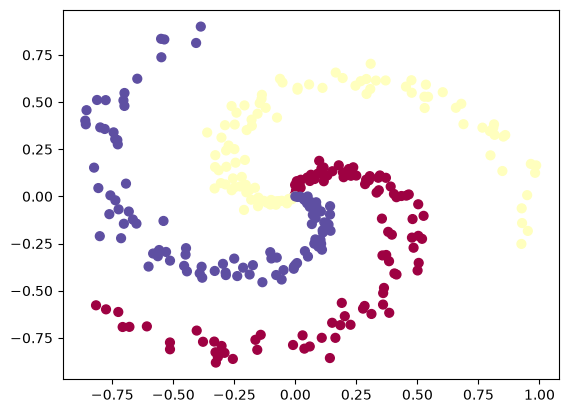

X.shape = (300, 2)
y.shape = (300,)


In [8]:
import numpy as np
from matplotlib import pyplot as plt

rng = np.random.default_rng()

N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype="uint8") # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + rng.standard_normal(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j
# lets visualize the data:
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.show()

print(f"{X.shape = }")
print(f"{y.shape = }")

# 2. Training the classifier

## 2.1 Initialize parameters

The linear score function is the following:

$$
f(x^i) = \sum_{d=0}^D {x_{d}^{i} \cdot w_d^k} + b^k
$$

which for every sample $x^i = [x^i_0, x^i_1]$, where $0 <= i < N \cdot K$, will perform the weighted sum between every dimension of the sample and the weights $w^k_j = [w_0, w_1]$, where $0 <= j < D$. This results in a single scalar value, so the above summation is performed `K` times, one for each class, so that the output is a vector with `K` values (note the `k` in `w^k`). For the bias, a vector with `K` dimensions is used, after the summation.

The summation operation can be performed with a dot product between two vectors:
$$
x^i \cdot w^k = x^i_0 \cdot w^k_0 + \ldots + x^i_{d-1} \cdot w^k_{d-1}
$$
which can then be repeated with every sample $i$ when $x$ is a matrix (for every component of the first dimension of $X$ perform the vector dot product with $w$). So the linear score funcion can be represented in matrix form:
$$
X \cdot w + b = \sum_{d=0}^D {x_{d}^{i} \cdot w_d^k} + b^k
$$

The final dimensions of each component are:
- `X.shape = (N*K, D)`
- `w.shape = (D, K)`
- `b.shape = (K,)`

In [9]:
w = 0.01 * rng.standard_normal((D, K)) # same as depecrated np.random.randn
b = np.zeros(K)
scores = X @ w + b

print(f"{w.shape = }")
print(f"{b.shape = }")
print(f"{scores.shape = }")

w.shape = (2, 3)
b.shape = (3,)
scores.shape = (300, 3)


## 2.2 Calculate the loss

For this classifier we are using the softmax so the loss for each sample $i$ its loss $L_i$ is
$$
L_i = -\log\left(\frac{e^{f^i_{y_{i}}}}{\sum_j e^{f^i_j}}\right)
$$
where $f^i$ is the class scores for the sample $i$, and $y_i$ is the correct class (expected label) for sample $i$.

As simply explained in the course source:
> We can see that the Softmax classifier interprets every element of f as holding the (unnormalized) log probabilities of the three classes. We exponentiate these to get (unnormalized) probabilities, and then normalize them to get probabilites. Therefore, the expression inside the log is the normalized probability of the correct class. Note how this expression works: this quantity is always between 0 and 1. When the probability of the correct class is very small (near 0), the loss will go towards (positive) infinity. Conversely, when the correct class probability goes towards 1, the loss will go towards zero because $\log(1) = 0$. Hence, the expression for $L_i$ is low when the correct class probability is high, and it’s very high when it is low.

The full loss function the sum between the mean of all sample losses and the regularization loss with strength $\lambda$:

$$
L = \frac{1}{N}\sum_i L_i + \frac{1}{2}\lambda \sum_k\sum_l W^2_{k,l}
$$

In [35]:
# e^{f_j} can produce really large numbers, which can provoke some numerical instability
# because floating point numbers have greater density around 0 (very small numbers)
# we could subract the maximum score to the rest of the scores (for each sample)
# to force the maximum value to be 0 so that max(e^f_j) = 1 (because e^0 = 1)
scores_adjusted = scores - scores.max(axis=0, keepdims=True)
expscores = np.exp(scores_adjusted)
probs = expscores / expscores.sum(axis=1, keepdims=True)

reg = 0.1
data_loss = np.mean(-np.log(probs))
reg_loss = 0.5 * reg * np.sum(w**2)
loss = data_loss + reg_loss
expected_loss = -np.log(1/3)
diff = np.abs(loss - expected_loss) # expected loss random init -> uniform 1/3 prob for each class
print(f"loss: {loss:.6f}; expected: -ln 1/3 = {expected_loss:.6f}; diff: {diff:.6f}")

loss: 1.098689; expected: -ln 1/3 = 1.098612; diff: 0.000077


## 2.3 Compute the Analytic Gradient

In order to understand how the computed scores should change to decrease the loss $L_i$ that this example contributes to the full loss $L$. We have to calculate the gradient ${\partial L_i} / {\partial f_k}$.

$$
\begin{align*}
    \frac{\partial L_i}{\partial f_k} = & \frac{\partial}{\partial f_k} \left[-\log \left(\frac{e^{f_{y_i}}}{\sum_j e^{f_j}}\right)\right]
                                        = -\frac{1}{e^{f_{y_i}} / \sum_j e^{f_j}} \frac{\partial}{\partial f_k} \left[\frac{e^{f_{y_i}}}{\sum_j e^{f_j}}\right] \\
                                      = & -\frac{\sum_j e^{f_j}}{e^{f_{y_i}}} \left( e^{f_{y_i}} \frac{\partial f_{y_i}}{\partial f_k} \frac{1}{\sum_j e^{f_j}} +
                                          e^{f_{y_i}} \left(-\frac{1}{(\sum_j e^{f_j})^2} \frac{\partial}{\partial f_k} \left[ \sum_j e^{f_j} \right] \right) \right) \\
                                      = & -\frac{\sum_j e^{f_j}}{e^{f_{y_i}}} \left( \frac{e^{f_{y_i}}}{\sum_j e^{f_j}} \frac{\partial f_{y_i}}{\partial f_k} -
                                          \frac{e^{f_{y_i}}}{\sum_j e^{f_j}} \left(\frac{1}{\sum_j e^{f_j}} \sum_j \frac{\partial e^{f_j}}{\partial f_k}\right)\right) \\
                                      = & -\frac{\sum_j e^{f_j}}{e^{f_{y_i}}} \left( \frac{e^{f_{y_i}}}{\sum_j e^{f_j}} \left(\mathbf{1}(y_i = k) - \frac{1}{\sum_j e^{f_j}}\sum_j\left[e^{f_j}\mathbf{1}(j=k)\right]\right)\right) \\
                                      = & -\frac{\sum_j e^{f_j}}{e^{f_{y_i}}} \left( \frac{e^{f_{y_i}}}{\sum_j e^{f_j}} \left(\mathbf{1}(y_i = k) - \frac{e^{f_k}}{\sum_j e^{f_j}} \right) \right) \\
                                      = & -\frac{\sum_j e^{f_j}}{e^{f_{y_i}}} \left( \frac{e^{f_{y_i}}}{\sum_j e^{f_j}} \mathbf{1}(y_i = k) - \frac{e^{f_k}e^{f_{y_i}}}{\left(\sum_j e^{f_j}\right)^2} \right) \\
                                      = & -\frac{\sum_j e^{f_j}}{e^{f_{y_i}}} \left( \frac{e^{f_{y_i}} \sum_j e^{f_j}\mathbf{1}(y_i = k) - e^{f_k}e^{f_{y_i}}}{\left(\sum_j e^{f_j}\right)^2} \right) \\
                                      = & -\frac{\sum_j e^{f_j}\mathbf{1}(y_i = k) - e^{f_k}}{\sum_j e^{f_j}} = \frac{e^{f_k}}{\sum_j e^{f_j}} - \frac{\sum_j e^{f_j}}{\sum_j e^{f_j}}\mathbf{1}(y_i = k) \\
                                      = & \frac{e^{f_k}}{\sum_j e^{f_j}} - \mathbf{1}(y_i = k).
\end{align*}
$$

Alternatively, by rewriting the loss, the derivative can be calculated much easier:
$$
\begin{align*}
    L_i
    = -\log\left(\frac{e^{f_{y_i}}}{\sum_j e^{f_j}}\right)
    = -f_{y_i} + \log\left(\sum_j e^{f_j}\right).
\end{align*}
$$

Then,
$$
\begin{align*}
    \frac{\partial L_i}{\partial f_k}
    &= -\frac{\partial f_{y_i}}{\partial f_k}
    + \frac{\partial}{\partial f_k}
      \log\left(\sum_j e^{f_j}\right) \\
    &= -\mathbf{1}(y_i = k)
    + \frac{1}{\sum_j e^{f_j}}
      \frac{\partial}{\partial f_k}
      \left[\sum_j e^{f_j}\right] \\
    &= -\mathbf{1}(y_i = k)
    + \frac{1}{\sum_j e^{f_j}}
      \sum_j e^{f_j}\mathbf{1}(j = k) \\
    &= -\mathbf{1}(y_i = k)
    + \frac{e^{f_k}}{\sum_j e^{f_j}}.
\end{align*}
$$

Therefore,
$$
\begin{align*}
    \boxed{
    \frac{\partial L_i}{\partial f_k}
    =
    \frac{e^{f_k}}{\sum_j e^{f_j}}
    - \mathbf{1}(y_i = k)
    }.
\end{align*}
$$